In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv


In [2]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
# Load train and test data
train_data = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv')
test_data = pd.read_csv('/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv')

       last contact date           age          job  marital  education  \
count              39211  39211.000000        38982    39211      37744   
unique              1013           NaN           11        3          3   
top           2009-05-15           NaN  blue-collar  married  secondary   
freq                 313           NaN         7776    22691      19584   
mean                 NaN     42.120247          NaN      NaN        NaN   
std                  NaN     12.709352          NaN      NaN        NaN   
min                  NaN     18.000000          NaN      NaN        NaN   
25%                  NaN     33.000000          NaN      NaN        NaN   
50%                  NaN     40.000000          NaN      NaN        NaN   
75%                  NaN     50.000000          NaN      NaN        NaN   
max                  NaN     95.000000          NaN      NaN        NaN   

       default        balance housing   loan   contact      duration  \
count    39211   39211.0000

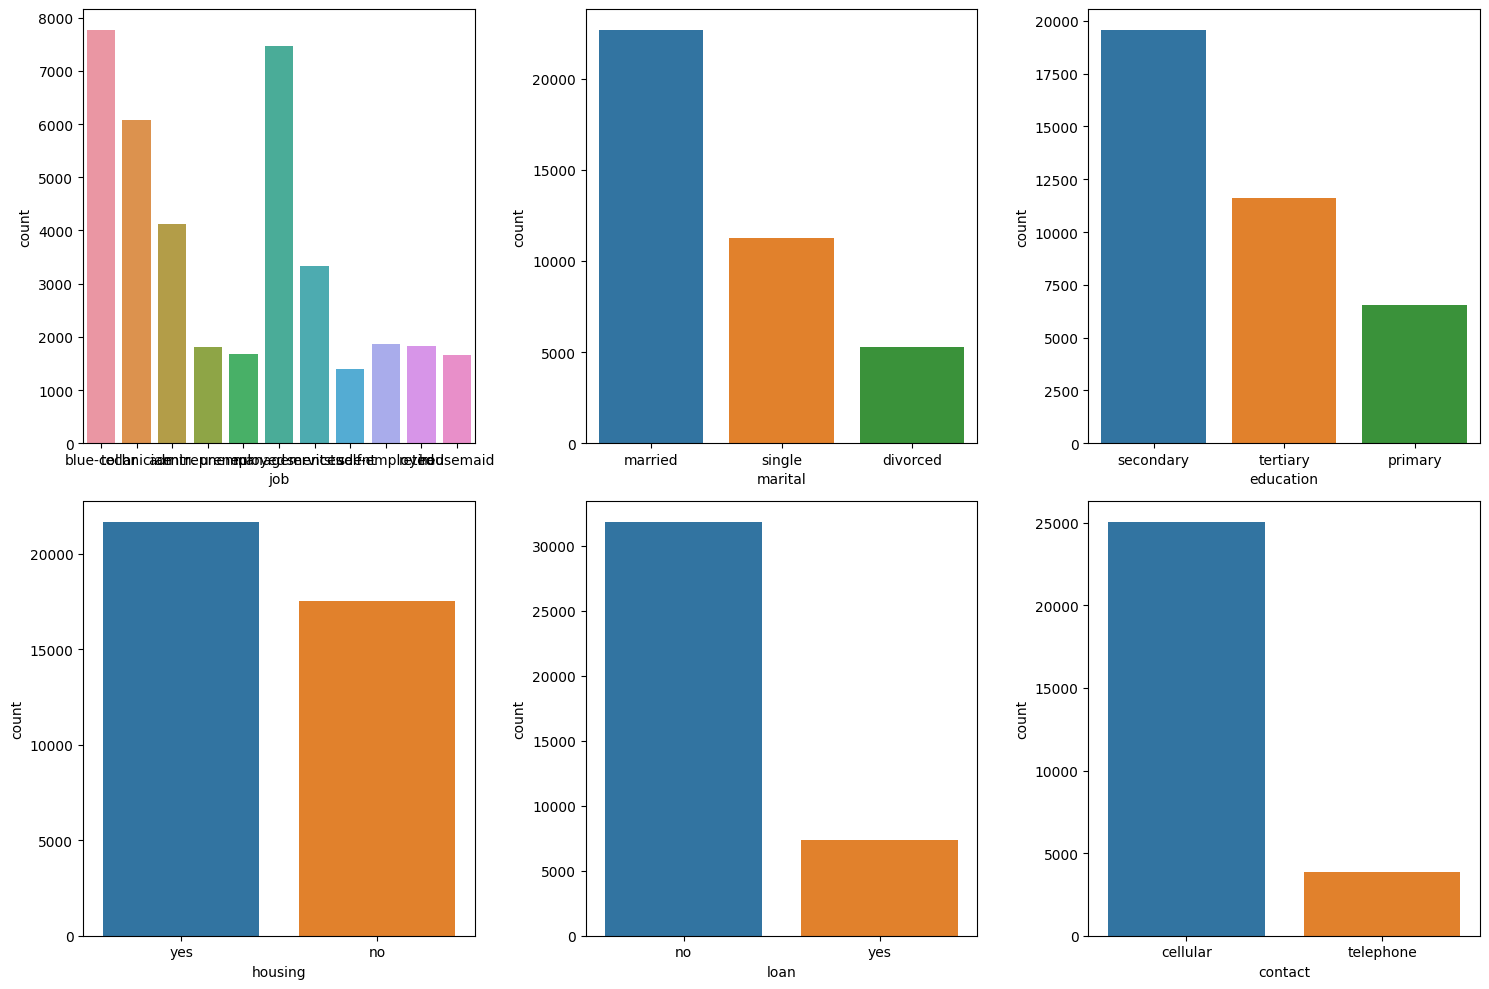

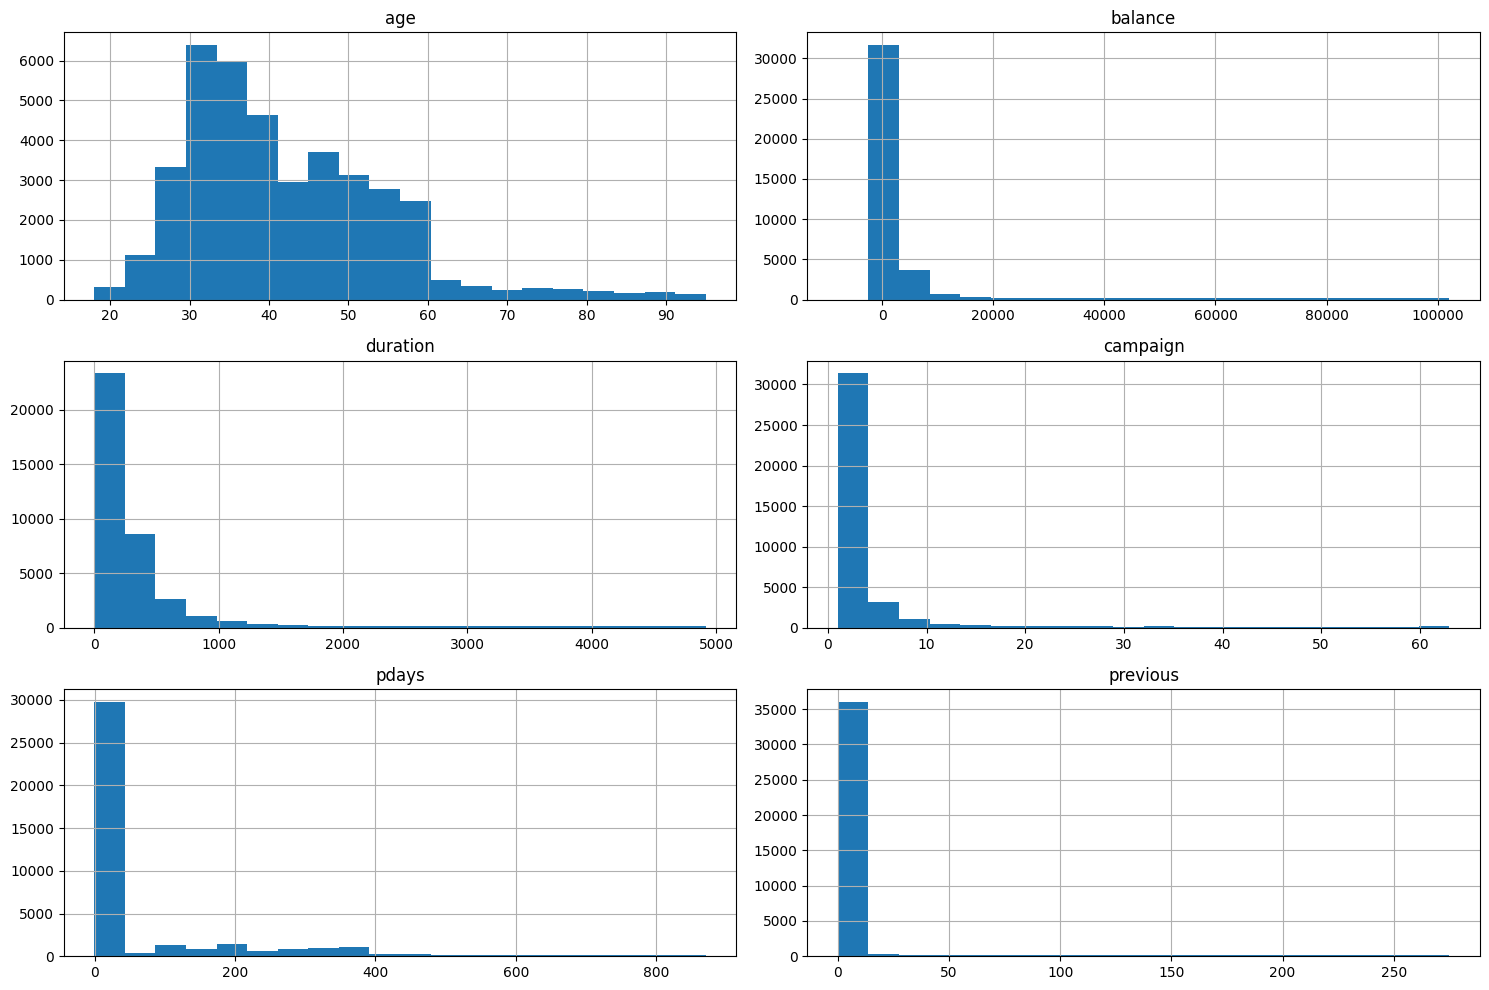

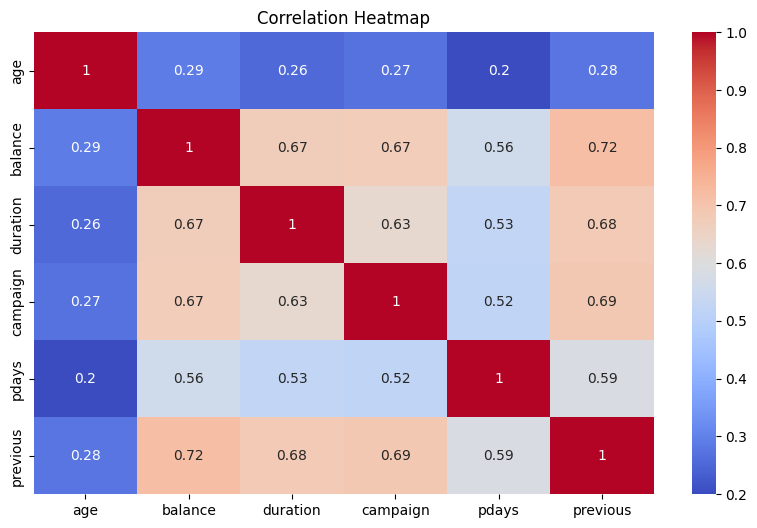

In [3]:
# Display basic information about the data
print(train_data.describe(include='all'))
print(test_data.describe(include='all'))

# Missing values
print("Train Missing Values:\n", train_data.isnull().sum())
print("Test Missing Values:\n", test_data.isnull().sum())

# Visualization: histograms and countplots (Distribution of categorical features)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.countplot(x='job', data=train_data, ax=axes[0, 0])
sns.countplot(x='marital', data=train_data, ax=axes[0, 1])
sns.countplot(x='education', data=train_data, ax=axes[0, 2])
sns.countplot(x='housing', data=train_data, ax=axes[1, 0])
sns.countplot(x='loan', data=train_data, ax=axes[1, 1])
sns.countplot(x='contact', data=train_data, ax=axes[1, 2])
plt.tight_layout()
plt.show()
train_data[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Correlation heatmap (Distribution of numerical features)
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [4]:
# Extract 'month' for potential seasonality effects
train_data['month'] = pd.to_datetime(train_data['last contact date']).dt.month
test_data['month'] = pd.to_datetime(test_data['last contact date']).dt.month

In [5]:
# Function to preprocess data
def preprocess_data(data, is_train=True):
    
    # Fill missing values in categorical columns with 'unknown' and duration with 0
    data['poutcome'] = data['poutcome'].fillna('unknown')
    data['contact'] = data['contact'].fillna('unknown')
    data['job'] = data['job'].fillna('unknown')
    data['education'] = data['education'].fillna('unknown')
    data['duration'] = data['duration'].fillna(0)  # No duration = no call
    # Label encoding 
    label_enc = LabelEncoder()
    for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']:
        data[col] = label_enc.fit_transform(data[col].astype(str))
    
    # Standardize numerical features
    num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    scaler = StandardScaler()
    data[num_cols] = scaler.fit_transform(data[num_cols])
    
       # Separate features and target variable if training data
    if is_train:
        X = data.drop(['target', 'last contact date'], axis=1)
        y = label_enc.fit_transform(data['target'])
        return X, y
    else:
        return data.drop(['last contact date'], axis=1)


In [6]:
# Preprocess training and test data
X_train, y_train = preprocess_data(train_data)
X_test = preprocess_data(test_data, is_train=False)

In [7]:
# Define pipelines for each model: 
models = {
    'Logistic Regression': Pipeline([
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('classifier', XGBClassifier(random_state=42, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()))
    ]),
}

In [8]:
# StratifiedKFold for balanced class representation in cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
# Evaluate each model using cross-validation and print F1 scores
for name, pipeline in models.items():
    f1_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='f1_macro')
    print(f"{name} Mean F1 Score: {np.mean(f1_scores):.4f}, Std F1 Score: {np.std(f1_scores):.4f}")

Logistic Regression Mean F1 Score: 0.5687, Std F1 Score: 0.0042
Random Forest Mean F1 Score: 0.7070, Std F1 Score: 0.0040
XGBoost Mean F1 Score: 0.7524, Std F1 Score: 0.0023


In [10]:
# Hyperparameter tuning for XGBoost
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1],
    'colsample_bytree': [0.6, 0.8, 1],
    'gamma': [0, 0.1, 0.3, 0.5],
    'min_child_weight': [1, 3, 5]
}

neg_class = (y_train == 0).sum()
pos_class = (y_train == 1).sum()
scale_pos_weight = neg_class / pos_class
xgb_clf = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=42, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.3],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.6, 0.8, 1]},
                   random_state=42, scoring='f1_macro', verbose=2)

In [11]:
best_params = random_search.best_params_
print("Best parameters found: ", best_params)

best_xgb = random_search.best_estimator_
best_xgb.fit(X_train, y_train)
y_test_pred = best_xgb.predict(X_test)

# Submission preparation
submission = pd.DataFrame({
    'id': test_data.index,
    'target': ['yes' if pred == 1 else 'no' for pred in y_test_pred]
})

submission_file_path = '/kaggle/working/submission.csv'
submission.to_csv(submission_file_path, index=False)

print(f"Submission file is: {submission_file_path}")

Best parameters found:  {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Submission file is: /kaggle/working/submission.csv
